**Содержание темы**

1. Теория

2. [Практический ноутбук 1](https://colab.research.google.com/drive/1EcHhwOCIhvm4mpxEbDGRawIJ4BpbAyqO?usp=sharing)

3. [Практический ноутбук 2](https://colab.research.google.com/drive/1pHONL5J4AVraE-SYJnpes7KdicPsD9qt?usp=sharing)

3. [Практический ноутбук 3](https://colab.research.google.com/drive/1tSOXY1AZ4-JrzlILL8bceAo2Syr3dJ2i?usp=sharing)


## Типы распознавания изображений

Выделяют четыре задачи распознавания изображений:

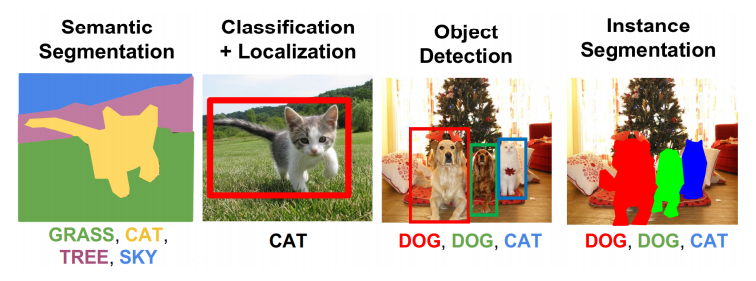



1. **Semantic segmentation.** Нейронная сеть на выходе для каждого пикселя выдаёт вероятность его принадлежности к каждому классу.
2. **Object recognition.** Нейронная сеть получает на вход изображение с ровно одним объектом и возвращает координаты содержащего объект прямоугольника и его класс.
3. **Object detection.** На картинке есть несколько объектов, сеть должна обвести прямоугольником и предсказать класс для каждого объекта. Заслуживают внимания архитектуры **Faster R-CNN** и **YOLO**.
4. **Instance segmentation.** Самая сложная задача - объектов может быть несколько, причём надо отличать друг от друга разные экземпляры одного класса.


## Семантическая сегментация

В данной лекции мы рассмотрим подходы к решению задачи семантической сегментации (**Semantic segmentation**), изучим, как использовать глубокие сверточные нейронные сети для сегментации изображений.

Также будет уделено внимание вопросам подготовки данных и построения моделей.

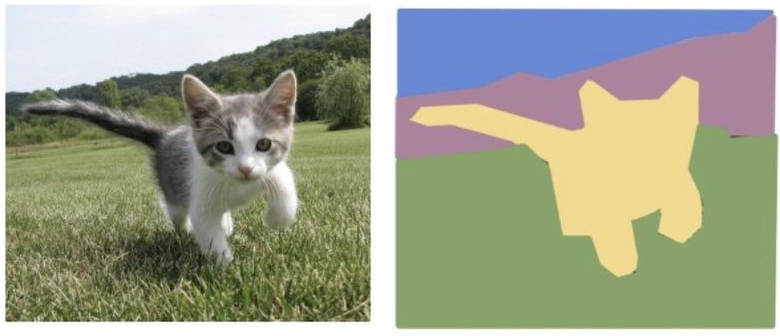

Глубокое обучение сверточных нейронных сетей (**CNN**) широко распространено в областях компьютерного зрения:
- классификация изображений;
- обнаружение объектов;
- генерация изображений и т.д.

Как и в прочих задачах компьютерного зрения, глубокое обучение превзошло другие методы сегментации изображений.

В задаче семантической сегментации наша цель - из исходного изображения размером **W × H × 3** получить матрицу **W × H**, содержащую предсказанные идентификаторы классов, соответствующие всем пикселям:

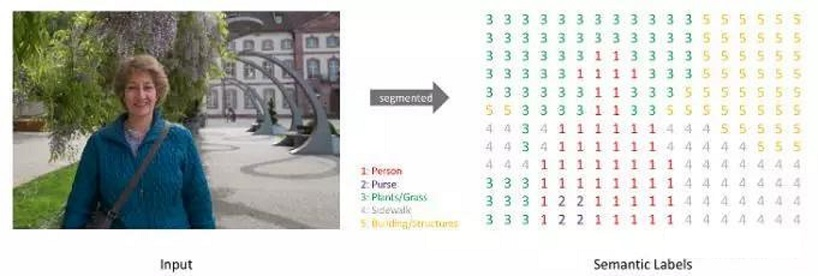


Как правило, в изображении с различными объектами мы хотим знать, какой пиксель принадлежит какому объекту. Например, на изображении вне помещения можно сегментировать небо, землю, деревья, людей и т. д.

Семантическая сегментация отличается от обнаружения объекта, поскольку она не показывает никаких ограничивающих рамок вокруг объекта. Также не делается различий между разными экземплярами одного и того же класса.

Например, в сцене может быть несколько автомобилей, и все они имеют одну и ту же метку класса.

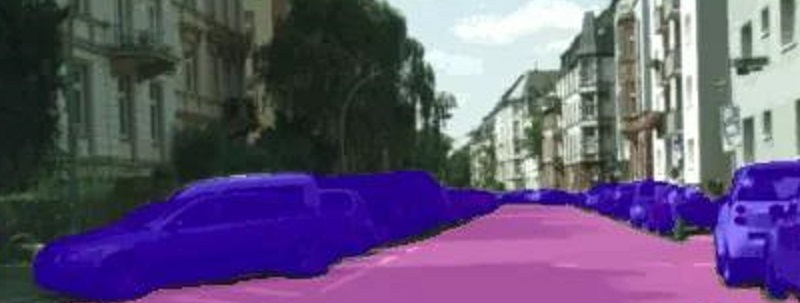

Чтобы выполнить семантическую сегментацию, требуется высокий уровень понимания изображения. Алгоритм должен определить класс существующего объекта и все пиксели объекта.

## Области применения

1.   Медицинские изображения

  Автоматическая сегментация снимков тела может помочь врачам в принятии решения о диагнозе. Например, модель можно обучить сегментировать опухоли.



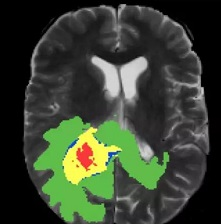

МРТ головного мозга: сегментация опухоли


2. Беспилотный автомобиль

  Беспилотники, такие как роботы-автомобили и дроны, нуждаются в автоматической сегментации. Например, беспилотным системам управления требуется обнаруживать участки для движения.



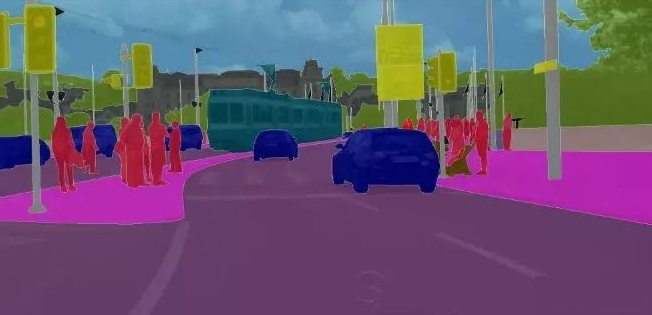

Сегментация дорожной сцены

3. Анализ спутниковых снимков

  Аэрофотоснимки и снимки со спутников можно использовать для разделения разных типов земель.



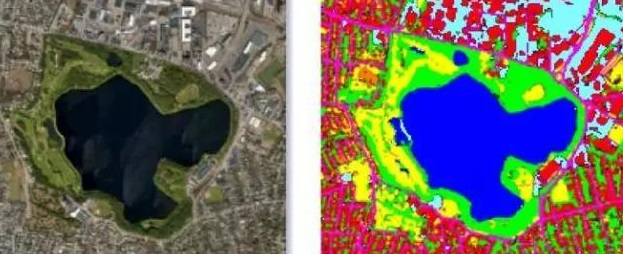

По мере развития глубокого обучения области применения семантической сегментация будут расширяться. Кроме того, семантическая сегментация может внедряться как часть составных систем, решая часть более сложной задачи.

## Сегментация изображений с использованием глубокого обучения

Как и в большинстве других приложений, использование CNN для семантической сегментации является очевидным выбором. При использовании CNN для семантической сегментации выход сети является также изображением, а не вектором фиксированной длины, как в случае полносвязной сети.

### Кодер и декодер

Как правило, архитектура модели включает несколько сверточных слоев, нелинейную активацию, пакетную нормализацию и слои объединения.

На начальных слоях модель изучает черты изображения низкого уровня, такие как края и цвета, а на более поздних слоях - черты высокого уровня, такие как различия объектов.

На ранних уровнях модели нейроны содержат информацию о небольшой области изображения, а на более поздних уровнях нейроны содержат информацию о большой области изображения. Следовательно, по мере добавления слоев размер изображения продолжает уменьшаться, а количество каналов продолжает увеличиваться.

В случае обычной классификации изображений (кошка - собака) нам необходимо передать пространственный тензор из сверточного слоя в вектор фиксированной длины. Для этого используется полносвязный слой, который теряет всю пространственную информацию.



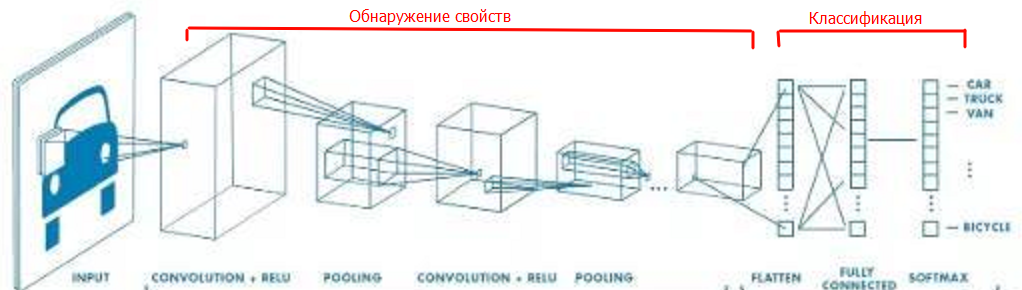

Для задачи семантической сегментации необходимо сохранить пространственную информацию, а потому полносвязные слои не будут использоваться. Такие сети называются полностью сверточными сетями - **_FCNN_**.

За счет комбинирования сверточных слоев с пулинговыми слоями и/или за счет смещений в сверточных слоях, производится дробление изображения с одновременным увеличением количества каналов. Тем самым создается пространственная матрица  небольшого размера с большим количеством каналов (карта признаков).

Далее производится обратное действие, с каждым слоем увеличивается размер матриц с одновременным уменьшением количества каналов.

Такой вид архитектуры уже вам знаком - это архитектура кодера-декодера. Слои, которые дробят (сжимают) входную информацию, составляют кодер, а слои, обратно развертывающие информацию к выходу, образуют декодер.

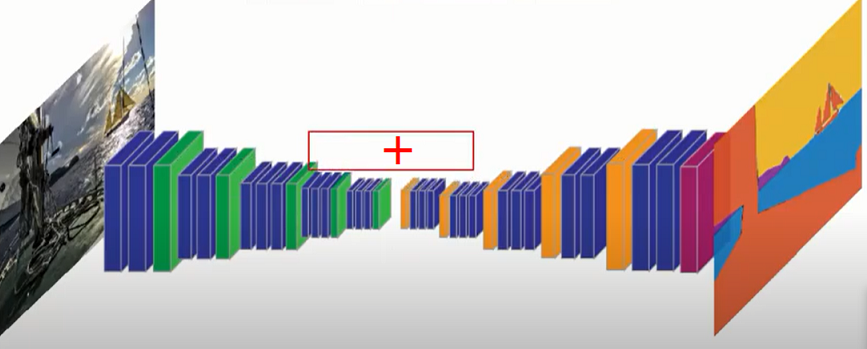

Сверточная модель, обученная для классификации изображений, содержит значимые признаки изображения, которые можно использовать и для сегментации. Мы можем повторно использовать сверточный слой предварительно обученной модели в составе кодировщика модели сегментации. Популярным выбором является использование моделей **ResNet** или **VGG**, предварительно обученных на наборе данных **ImageNet**.

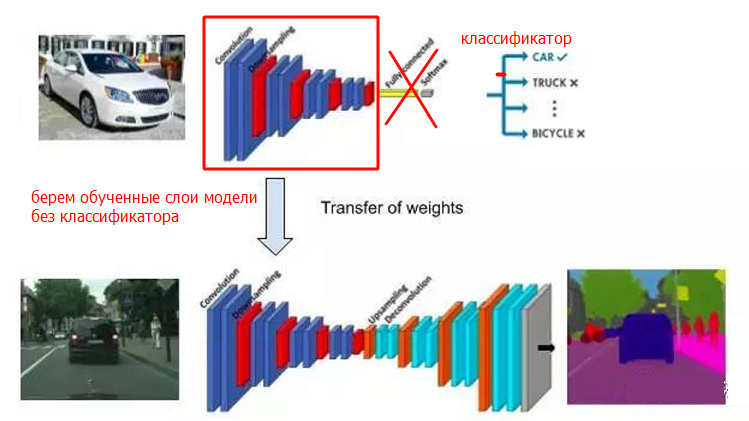

### Пробрасывание информации. Латеральные связи.

Но если мы просто соберем модель из последовательных слоев кодера и декодера, то низкоуровневая информация может быть потеряна при сжатии. Следовательно, границы в карте сегментации, сгенерированной декодером, могут быть неточными и размытыми.

Чтобы восполнить недостающую информацию, можно передать (пробросить) низкоуровневую информацию со слоев кодера на слои декодера, объединив ее с информацией, передаваемой в декодере основным путем. Таким образом формируются ***латеральные*** (боковые, или пропускные) связи в модели нейронной сети.

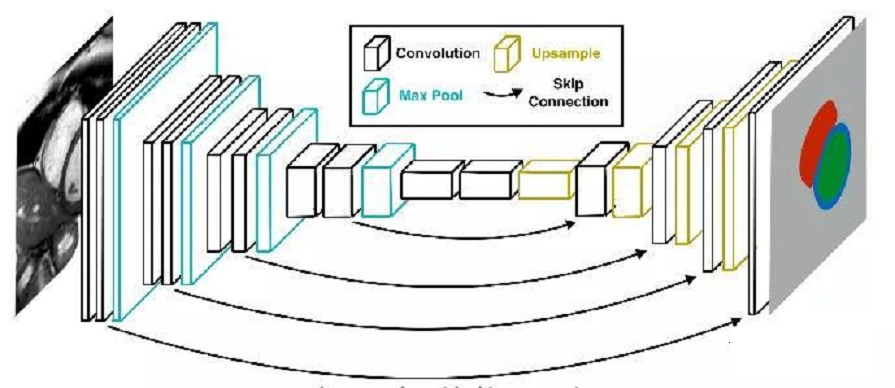

Кодер-декодер с латеральными связями

Пропускное соединение с более раннего уровня предоставляет слою декодера дополнительную информацию, необходимую для создания точной границы.

### Как обучать?

Сравнивая каждый пиксель выводимого сетью изображения (**y_pred**) с верным сегментированным изображением (**y_true**), мы находим ошибки, применяя функцию потери кросс-энтропии к каждому пикселю. Затем в модели вычисляются частные производные и пересчитываются веса нейронов для следующей итерации обучения.

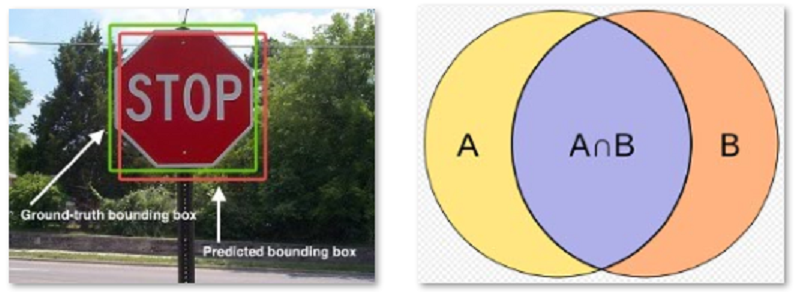


В качестве меры точности применяются следующие функции:

[Коэффициент Сёренсена – Дайса - Sørensen–Dicе](https://ru.wikipedia.org/wiki/%D0%9A%D0%BE%D1%8D%D1%84%D1%84%D0%B8%D1%86%D0%B8%D0%B5%D0%BD%D1%82_%D0%A1%D1%91%D1%80%D0%B5%D0%BD%D1%81%D0%B5%D0%BD%D0%B0)

Коэффициент Сёренсена–Дайса равен удвоенному количеству элементов, общих для обоих наборов, деленному на сумму количеств элементов в каждом наборе. Иначе говоря, коэффициент Сёренсена–Дайса равен удвоенной мощности пересечения множеств, деленному на сумму мощностей каждого множества.

Поскольку в знаменателе фигурирует сумма количеств элементов в каждом множестве без вычитания количества элементов объединения множеств, то в числителе объем пересечения удваивается. Тогда если множества полностью совпали, то **|A| = |B| = |A ∩ B|** и коэффициент Дайса даст **1**.

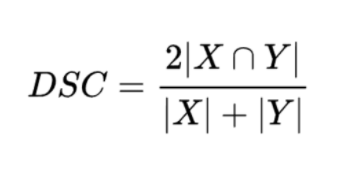


[Коэффициент Жаккара](https://ru.wikipedia.org/wiki/%D0%9A%D0%BE%D1%8D%D1%84%D1%84%D0%B8%D1%86%D0%B8%D0%B5%D0%BD%D1%82_%D0%96%D0%B0%D0%BA%D0%BA%D0%B0%D1%80%D0%B0)  - отношение мощности (числа элементов) пересечения двух множеств к мощности их объединения.

В числителе дроби стоит мощность пересечения множеств, а в знаменателе — общее количество элементов двух множеств (мощность объединения).

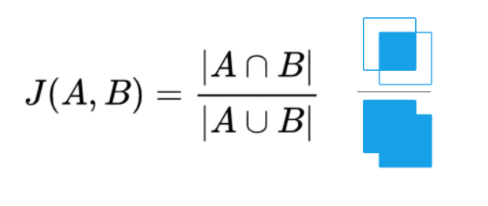

При обучении нейронной сети ей нужно дать критерий того, насколько сгенерированное ею сегментированное изображение (**y_pred**) совпадает с верной маской сегментации (**y_true**).

Для этого нужно сравнить сегменты из **y_pred** с сегментами из **y_true**.

Рассмотрим расчет коэффициентов на примере простых числовых множеств:

In [ ]:
a = [3, 5, 9, 12, 4, 7, 8, 3]
b = [9, 4, 12, 78, 1, 2]

set_a = set(a)
set_b = set(b)

print('Множество set_a:', set_a)
print('Множество set_b:', set_b)

Множество set_a: {3, 4, 5, 7, 8, 9, 12}
Множество set_b: {1, 2, 4, 9, 12, 78}


Вариант расчета коэффициента Жаккара:

In [ ]:
def jaccard(x, y):

    z = x.intersection(y)
    u = x.union(y)
    print("Пересечение:", z)
    print("Объединение:", u)

    return len(z) / len(u)


print("Коэффициент Жаккара:", jaccard(set_a, set_b))

Пересечение: {9, 4, 12}
Объединение: {1, 2, 3, 4, 5, 7, 8, 9, 12, 78}
Коэффициент Жаккара: 0.3


Вариант расчета коэффициента Дайса. Чтобы при пустых множествах **X** и **Y** не получилось деления на **0**, в числителе и знаменателе иногда добавляют **1**.

In [ ]:
def dice(x, y):

    z = x.intersection(y)
    print("Пересечение:", z)
    print("Мощность 1-го множества:", len(x))
    print("Мощность 2-го множества:", len(y))

    return (2. * len(z) + 1) / (len(x) + len(y) + 1)


print("Коэффициент Дайса:", dice(set_a, set_b))

Пересечение: {9, 4, 12}
Мощность 1-го множества: 7
Мощность 2-го множества: 6
Коэффициент Дайса: 0.5


Совпадение двух множеств должно давать **1**. Проверим это:

In [ ]:
print("Коэффициент Жаккара:", jaccard(set_a, set_a))
print()
print("Коэффициент Дайса:", dice(set_a, set_a))

Пересечение: {3, 4, 5, 7, 8, 9, 12}
Объединение: {3, 4, 5, 7, 8, 9, 12}
Коэффициент Жаккара: 1.0

Пересечение: {3, 4, 5, 7, 8, 9, 12}
Мощность 1-го множества: 7
Мощность 2-го множества: 7
Коэффициент Дайса: 1.0


Вне завимисимости от типа применямой метрики задача состоит в том, чтобы в процессе обучения сети сегменты **y_pred** становились все ближе к сегментам из **y_true**, тогда и метрика на основе `dice()` или `jaccard()` между верно сегментированной картинкой и ответом модели будет стремиться к **1**.

На основе этих метрик можно построить функцию ошибки (**loss**), которая и позволит рассчитать градиенты для изменения весов модели на каждом шаге обучения.

### Данные для обучения и их расширение

Первым шагом в обучении модели сегментации является подготовка набора данных. Нам нужно ввести изображение **RGB** и верно сегментированное изображение. Если вы хотите создать свой собственный набор данных, вы можете использовать такие инструменты, как **labelme** или **GIMP**, чтобы вручную сгенерировать верную маску сегментации для размечаемых изображений.

Назначьте уникальный идентификатор (метку) каждому классу. В сегментированном изображении значение пикселя должно представлять идентификатор класса соответствующего пикселя. Это общий формат, используемый в большинстве наборов данных и **keras_segmentation**. Для изображений сегментации не используйте формат **jpg**, потому что это формат сжатия с потерями и значение пикселя может измениться. Вместо этого используйте форматы без потерь, такие как **BMP** или **PNG**.

---

**Важно!** Размер входного и сегментированного изображения должен быть одинаковым.

---

Если данных мало, то их можно расширить с помощью методов агументации, применив случайные преобразования к изображению. Можно изменить оттенок, насыщенность, яркость и другие цветовые атрибуты входного изображения. Также можно применять такие преобразования, как вращение, масштабирование и отражение. Для преобразования, которое изменяет положение пикселя, верно сегментированное изображение должно быть преобразовано тем же образом.
Данные действия нужно применить согласованно как к входным картинкам, так и к сегментированным картинкам.

Это можно сделать самим (см. лецию о сверточных сетях) или используя готовые методы, например - **Imgaug**, **Albumentations**, **ImageDataGenerator** и др.

## Модели для сегментации изображений

### FCN
на основе [VGG16 и более поздних](https://keras.io/api/applications/vgg/)

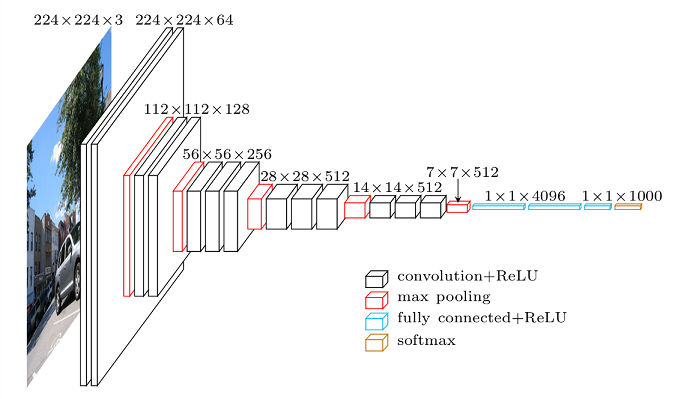

**VGG** - модель классификации, предложенная Оксфордским университетом, которая в конкурсе **ImageNet 2013** достигла точности **92,7%**. По сравнению с **ResNet**, у нее меньше уровней, поэтому скорость обучения выше. Для большинства существующих тестов сегментации **VGG** не работает так же хорошо в отношении точности, как **ResNet**. До **ResNet** **VGG** была стандартной предварительно обученной моделью для широкого ряда приложений.

**FCN** - одна из первых предложенных моделей сквозной семантической сегментации. Здесь стандартные модели классификации изображений, такие как **VGG** и [AlexNet](https://www.mydatahack.com/building-alexnet-with-keras/), преобразуются в полную свертку, выполняя свертку уровня **FC 1x1**. В **FCN** транспонированная свертка используется для повышения частоты дискретизации, в отличие от других методов, использующих математическую интерполяцию. Эти три варианта - [FCN8, FCN16 и FCN32](https://www.programmersought.com/article/68376227056/). В **FCN8** и **FCN16** используются пропускные (латеральные) соединения.

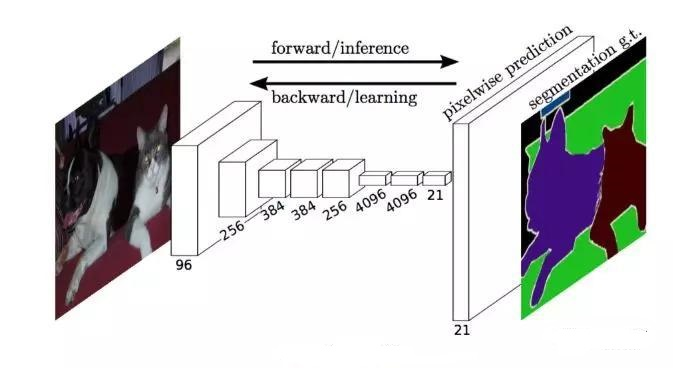

###[ ResNet](https://keras.io/api/applications/resnet/)

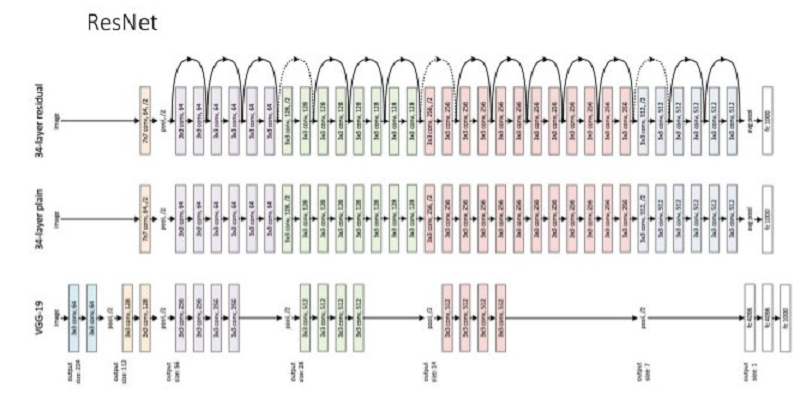

**ResNet** - модель классификации, предложенная Microsoft, которая в конкурсе **ImageNet 2016** достигла точности 96,4%.

**ResNet** используется в качестве модели предварительного обучения для многих приложений. Модель **ResNet** имеет большое количество слоев и латеральных соединений, что повышает возможности ее обучения.

В модели **ResNets** решена **проблема исчезающего градиента**. Напомним, исчезновение градиента происходит, когда сеть достаточно глубокая и градиенты, из которых рассчитывается функция потерь, легко уменьшаются до нуля после нескольких применений правила обратного распространения ошибки. Таким образом, веса ранних слоев никогда не обновляют свои значения и не обучаются совсем.

В случае с **ResNet** градиенты могут проходить напрямую через латеральные соединения в обратном направлении от более поздних слоев к начальным фильтрам, позволяя весам ранних слоев также изменяться.

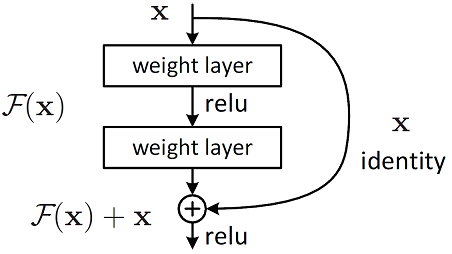

Поскольку нейронные сети являются хорошими приближениями функций, они должны быть в состоянии легко приблизить ***тождественное отображение (identity function)***, где выход функции равен входу:

$I(x) = x$

Следуя той же логике, если мы пропустим выход c предыдущего слоя модели и объединим его с выходом следующего слоя, сеть должна быть в состоянии предсказать любую функцию, которую она изучала ранее, с добавленным входом.

$H(x) = x + F(x)$

Идея заключается в том, что при $F(x) = ReLU$ производная функции в отрицательной области равна **0**, и тогда разница между входом и выходом блока вычисляется без потерь.

### [SegNet](hhttps://github.com/imlab-uiip/keras-segnet)

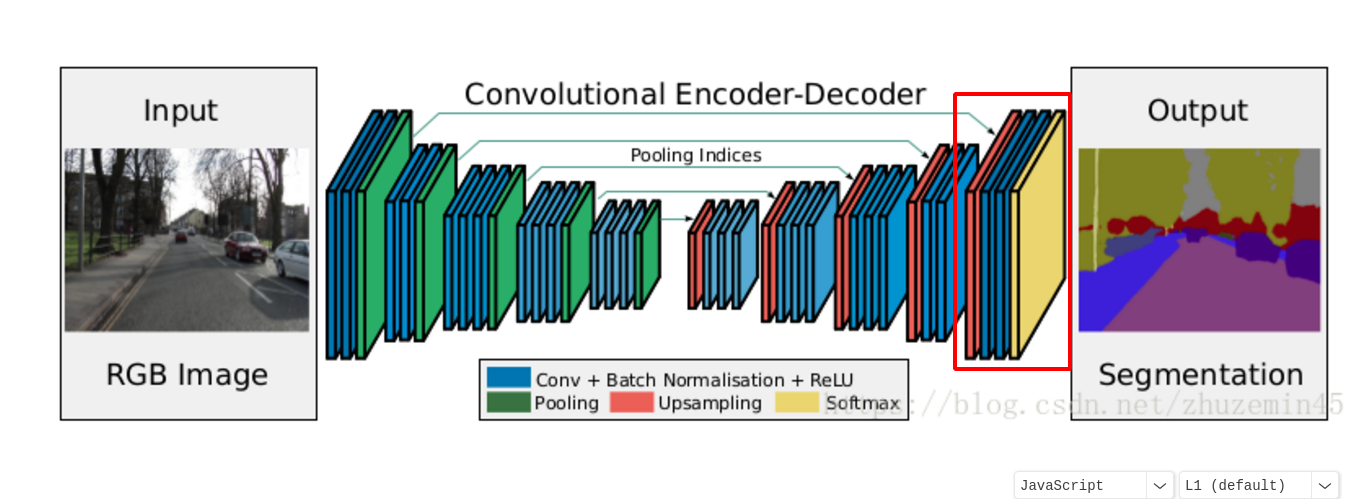

Архитектура **SegNet** использует структуру кодера-декодера. Слои кодера и декодера симметричны друг другу. Операция повышения дискретизации уровня декодера использует максимальный индекс пула соответствующего уровня кодера. **SegNet** не имеет латеральных соединений. В отличие от **FCN**, для повышения частоты дискретизации в модели нет обучаемых параметров.
Во время повышающей дискретизации используется индекс положения пикселя **Max Value**, записанный во время понижающей выборки.

https://arxiv.org/abs/1511.00561

### [U-Net](https://arxiv.org/pdf/1505.04597.pdf)

Архитектура **U-net** сети представляет собой последовательность слоёв свёртка+пулинг, которые сначала уменьшают пространственное разрешение картинки, а потом увеличивают его, предварительно объединив с данными картинки и пропустив через другие слои свёртки. Таким образом, сеть выполняет роль своеобразного многоступенчатого фильтра.

Для обучения сети используется коэффициент Дайса (**Dice coefficient**).

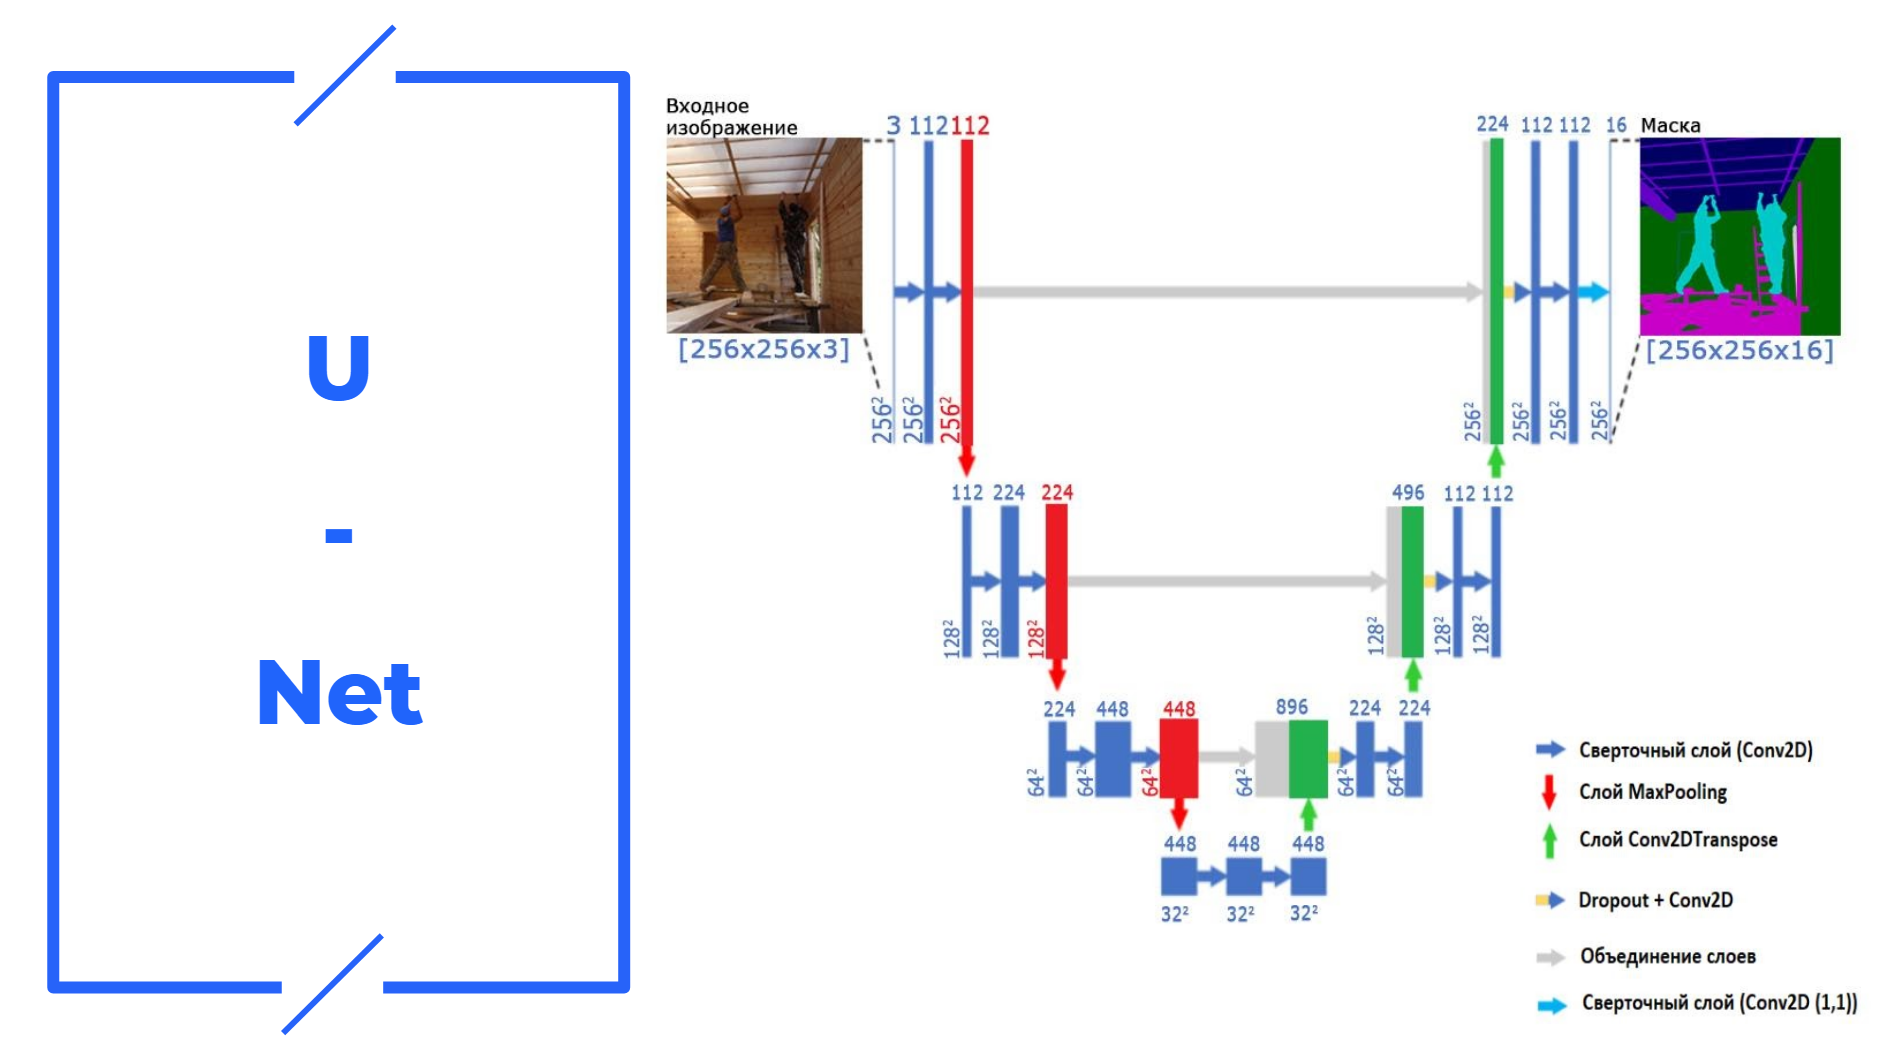

### [PSPnet](https://arxiv.org/abs/1612.01105)

Модель **PSPnet** оптимизирована для глубокого изучения изображения. Сначала изображение передается во входной сверточный блок для получения карты признаков. Далее карту признаков с помощю слоев пулинга с разным размером ядра сужают до трех разных масштабов. Затем применяются свертки, после чего все карты признаков подвергаются развертыванию слоями апсемплинга до общего размера матриц, и соединяются вместе. Наконец, выходной сверточный блок используется для получения окончательного сегментированного изображения.

В **PSPnet** более мелкие объекты хорошо захватываются за счет объединения объектов в высоком разрешении, а более крупные объекты фиксируются за счет объединения объектов меньшего разрешения.

Для изображений, содержащих сцены в помещении и на открытом воздухе, лучше всего выбрать **PSPNet**, поскольку объекты обычно бывают разных размеров. Размер входной картинки здесь должен быть довольно большим, примерно **500x500**, что делает модель достаточно "тяжелой".

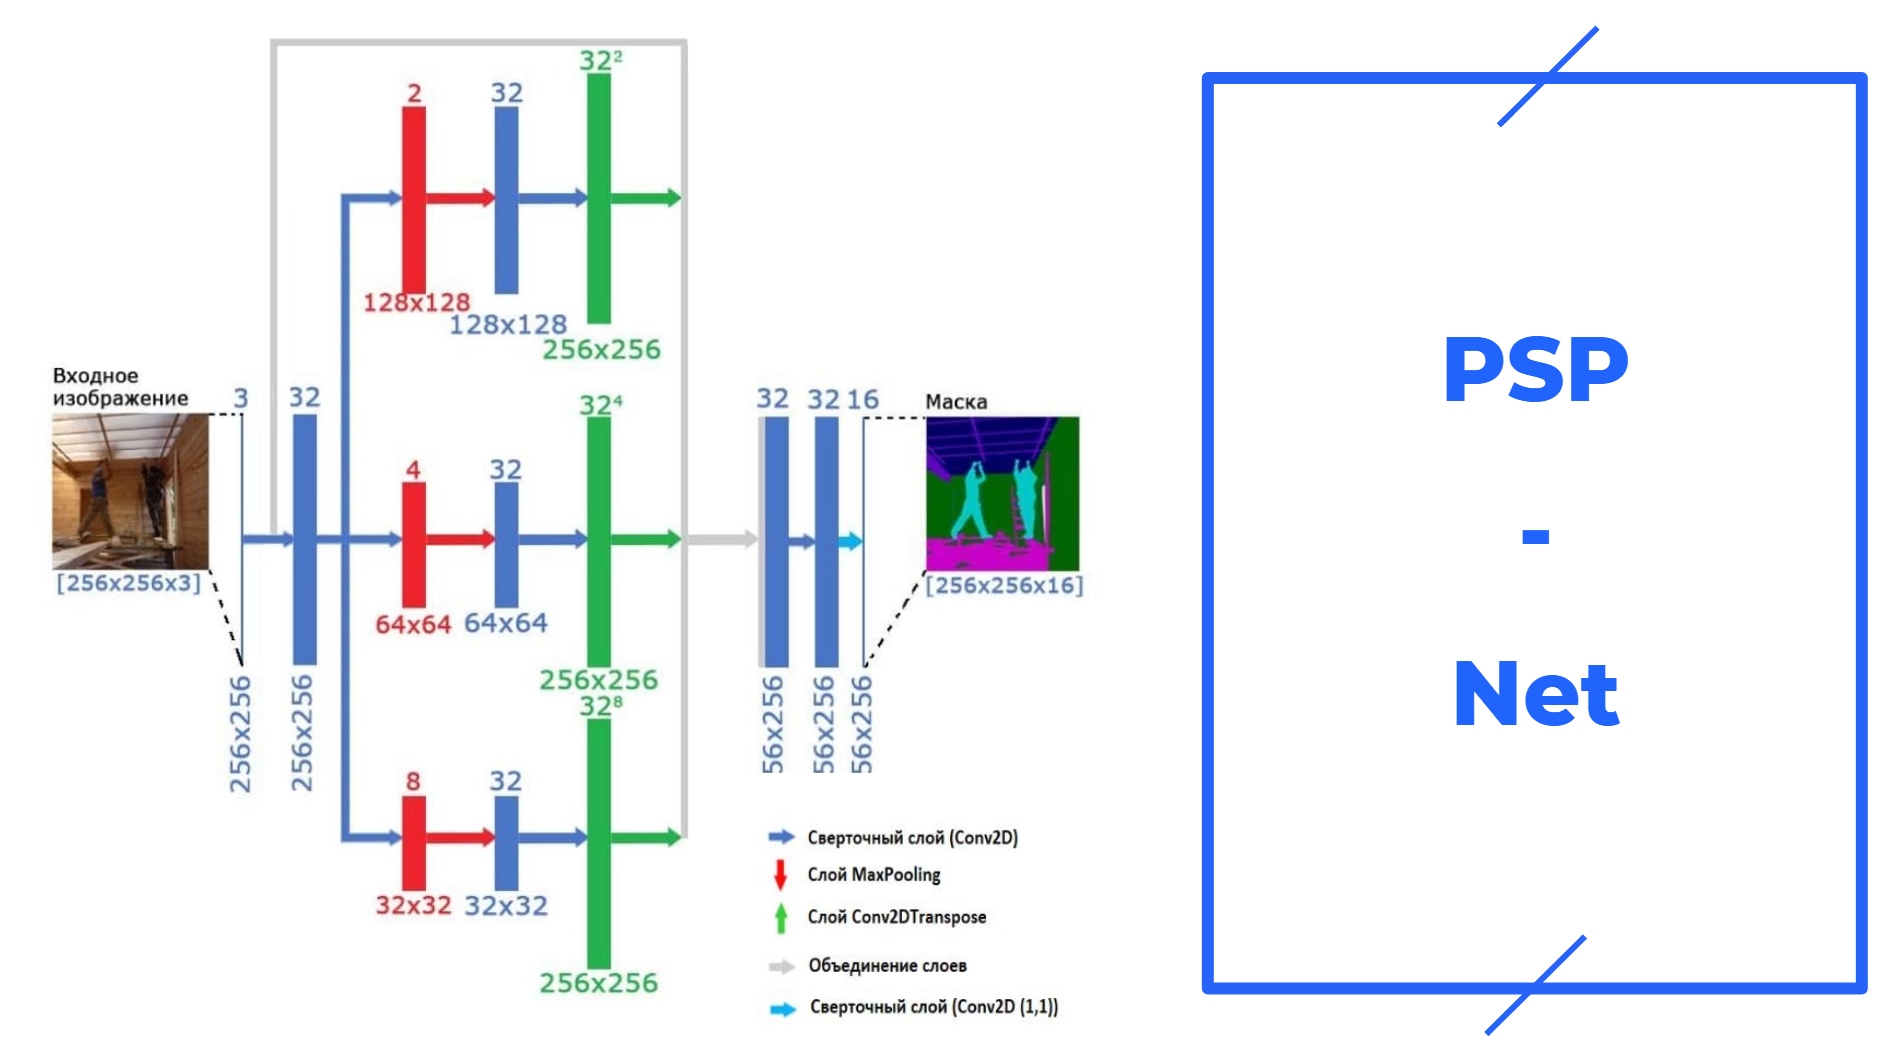

### Рекомендации

Для сегментации изображений в области медицины популярным выбором является архитектура **U-Net**. Благодаря латеральным связям **U-Net** не упустит подробностей. **U-Net** также может использоваться в сценах с небольшими объектами в помещении или на улице.

Для простого набора изображений большого размера и небольшим количеством объектов **U-Net** и **PSPNet** могут быть избыточно сложными. В этом случае достаточно простых моделей, таких как **FCN** или **Segnet**.

Рекомендуется испытать несколько моделей сегментации с разными размерами входных изображений.

Если вы не хотите писать свою собственную модель, вы можете импортировать готовую модель из модуля **keras_segmentation**.

        import keras_segmentation

        model = keras_segmentation.models.unet.vgg_unet(n_classes=51 , input_height=416, input_width=608 )

**Содержание темы**

1. Теория

2. [Практический ноутбук 1](https://colab.research.google.com/drive/1EcHhwOCIhvm4mpxEbDGRawIJ4BpbAyqO?usp=sharing)

3. [Практический ноутбук 2](https://colab.research.google.com/drive/1pHONL5J4AVraE-SYJnpes7KdicPsD9qt?usp=sharing)

3. [Практический ноутбук 3](https://colab.research.google.com/drive/1tSOXY1AZ4-JrzlILL8bceAo2Syr3dJ2i?usp=sharing)
